# A3T-GCN: APS Grid Load Forecasting (FINAL with synthetic augmentation)
**Attention Temporal Graph Convolutional Network** — next-hour net load prediction.

| | |
|---|---|
| **Dataset** | `model_training_data_augmented.csv` — 441,847 rows (real + synthetic) |
| **Graph** | `edges_realistic.csv` — 119 distribution-line edges |
| **Target** | `target_net_load_kw_t_plus_1` |
| **Features** | 79 raw → 26 temporal + 6 node (leakage/zero-var removed) |

### What's new vs previous version
| Update | Effect |
|---|---|
| **Synthetic heat events added** | +148% extreme-heat hours, +612% event hours |
| **Huber loss** (replaces MSE) | Robust to outlier buses |
| **Dropout 0.3**, stronger GRU weight decay (5e-4) | Closes train/val gap |
| **Two-phase LR** (1e-3 → 2e-4) | Fine-tunes past plateau |
| **sMAPE on load buses only** | Fixes inflated MAPE artifact |
| **Bug fixes** | Load-bus plot, empty-scenario bar, correct risk-tier direction |

---
### Table of Contents
1. [Install & Imports](#1)
2. [Configuration](#2)
3. [Feature Selection](#3)
4. [Data Loading & Preprocessing](#4)
5. [EDA](#5)
6. [Graph Construction](#6)
7. [Dataset & DataLoader](#7)
8. [A3T-GCN Model](#8)
9. [Training — Phase 1](#9)
10. [Training — Phase 2](#10)
11. [Evaluation & Scenario Analysis](#11)
12. [Decision Layer](#12)
13. [Save & Inference](#13)


## 1. Install & Imports <a id="1"></a>

In [1]:
# !pip install torch torch-geometric pandas numpy scikit-learn matplotlib networkx

import os, warnings, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')


/opt/anaconda3/envs/tf/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch : 2.9.0
Device  : cpu


## 2. Configuration <a id="2"></a>

Two-phase training: Phase 1 @ LR=1e-3 for `EPOCHS_P1` epochs, then Phase 2 restarts from best checkpoint at LR=2e-4 for `EPOCHS_P2` more epochs.

In [2]:
class Cfg:
    # File paths — point to augmented dataset
    DATA_PATH  = 'model_training_data_augmented.csv'
    EDGES_PATH = 'edges_realistic.csv'

    # Temporal window
    SEQ_LEN      = 24
    PRED_HORIZON = 1
    TARGET       = 'target_net_load_kw_t_plus_1'

    # Model — dropout bumped 0.2 → 0.3
    GCN_HIDDEN = 64
    GCN_OUT    = 32
    GRU_HIDDEN = 64
    DROPOUT    = 0.3

    # Phase 1: warm-up
    EPOCHS_P1 = 60
    BATCH     = 32
    LR        = 1e-3

    # Phase 2: fine-tune from best checkpoint
    EPOCHS_P2 = 40
    LR_P2     = 2e-4

    # Weight decay — GRU gets stronger decay (primary overfit source)
    WD_BASE = 1e-4
    WD_GRU  = 5e-4

    HUBER_DELTA = 1.0
    TRAIN_FRAC = 0.70
    VAL_FRAC   = 0.15

cfg = Cfg()
print('Config ready.')
print(f'  Phase 1: {cfg.EPOCHS_P1} epochs @ LR={cfg.LR}')
print(f'  Phase 2: {cfg.EPOCHS_P2} epochs @ LR={cfg.LR_P2}')


Config ready.
  Phase 1: 60 epochs @ LR=0.001
  Phase 2: 40 epochs @ LR=0.0002


## 3. Feature Selection (79 → 32) <a id="3"></a>

RF importance + domain analysis drove these selections.

| Dropped group | Reason |
|---|---|
| `apparent_load_kva`, `baseline_utilization`, `rooftop_solar_fraction` | Derived from target — **leakage** |
| `base_kv` | Constant 12.47 kV — zero variance |
| Raw `hour`, `dayofweek`, `month`, `dayofyear` | Superseded by sin/cos |
| `is_evening` | Redundant with `hour_sin/cos` + peak flag |
| `lag_2/3/6/48` | Covered by lag_1/12/24/168 + rolling means |
| `rollmean_6h`, `rollmax_6h` | Covered by 3h and 24h neighbours |
| `temp_f`, rollmeans | lag_24 dominates; others add collinearity |
| 6 event one-hot dummies | <0.2% each; `is_event_window` binary sufficient |
| `power_factor`, `bus_type`, etc. | Near-zero RF importance |
| `Unnamed: 78` | Fully null |


In [3]:
TS_FEATURES = [
    # Core load
    'net_load_kw', 'gross_load_kw', 'net_load_kvar',
    'baseline_ev_kw', 'rooftop_solar_kw',
    # Lags: 1h, 12h, 24h, 168h
    'net_load_kw_lag_1', 'net_load_kw_lag_12',
    'net_load_kw_lag_24', 'net_load_kw_lag_168',
    # Rolling
    'net_load_kw_rollmean_3h', 'net_load_kw_rollmean_24h',
    'net_load_kw_rollmax_24h', 'net_load_ramp_1h', 'net_load_ramp_24h',
    # Cyclical time
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos',
    # APS flags
    'is_peak_window_aps', 'is_overnight_ev_window', 'is_weekend',
    # Weather (lag versions)
    'temp_f_lag_24', 'irradiance_wm2_lag_24', 'irradiance_wm2_lag_168',
    'cooling_excess_f', 'extreme_heat_flag', 'heatwave_flag',
    # Event
    'is_event_window',
]

NODE_FEATURES = [
    'capacity_kw', 'distance_from_substation',
    'ev_weight', 'solar_weight', 'temp_sensitivity', 'branch_depth',
]

print(f'Temporal : {len(TS_FEATURES)} | Node : {len(NODE_FEATURES)}')


Temporal : 30 | Node : 6


## 4. Data Loading & Preprocessing <a id="4"></a>

The augmented CSV adds a `is_synthetic` flag column. The loader prints the real/synthetic breakdown for transparency.

In [4]:
df = pd.read_csv(cfg.DATA_PATH, parse_dates=['timestamp'])
df = df.sort_values(['timestamp','bus_id']).reset_index(drop=True)
if 'Unnamed: 78' in df.columns:
    df = df.drop(columns=['Unnamed: 78'])

print(f'Shape: {df.shape}')
if 'is_synthetic' in df.columns:
    real = (df['is_synthetic']==0).sum()
    syn  = (df['is_synthetic']==1).sum()
    print(f'  Real rows      : {real:,}')
    print(f'  Synthetic rows : {syn:,}  ({syn/len(df)*100:.1f}%)')
    print(f'  Extreme heat hours  : {(df["extreme_heat_flag"]==1).sum():,}')
    print(f'  Event window hours  : {(df["is_event_window"]==1).sum():,}')

print(f'Buses     : {df["bus_id"].nunique()}')
print(f'Timestamps: {df["timestamp"].nunique()}')
print(f'Target nulls: {df[cfg.TARGET].isnull().sum()}')
df.head(3)


Shape: (441847, 79)
  Real rows      : 369,487
  Synthetic rows : 72,360  (16.4%)
  Extreme heat hours  : 121,380
  Event window hours  : 84,185
Buses     : 44
Timestamps: 10248
Target nulls: 0


,timestamp,bus_id,gross_load_kw,baseline_ev_kw,rooftop_solar_kw,net_load_kw,net_load_kvar,temp_f,irradiance_wm2,heatwave_flag,...,temp_f_rollmean_24h,net_load_kw_rollmax_6h,net_load_kw_rollmax_24h,net_load_ramp_1h,net_load_ramp_24h,target_net_load_kw_t_plus_1,target_net_load_kw_t_plus_24,target_utilization_t_plus_1,target_utilization_t_plus_24,is_synthetic
0,2024-01-17,E01,0.000000,0.00,0.0,0.000000,0.000000,88.570364,0.0,0,...,88.570364,0.000000,0.000000,0.0,0.0,0.000000,0.000000,NaN,NaN,1
1,2024-01-17,E02,68.523867,0.58,0.0,68.523867,22.844723,88.570364,0.0,0,...,88.570364,68.523867,68.523867,0.0,0.0,63.456772,67.538144,0.155553,0.174368,1
2,2024-01-17,E03,68.974752,0.62,0.0,68.974752,22.997167,88.570364,0.0,0,...,88.570364,68.974752,68.974752,0.0,0.0,66.849149,67.172957,0.172972,0.188028,1


In [5]:
bus_ids    = sorted(df['bus_id'].unique())
bus_index  = {b: i for i, b in enumerate(bus_ids)}
timestamps = sorted(df['timestamp'].unique())
N, T = len(bus_ids), len(timestamps)
F_ts, F_node = len(TS_FEATURES), len(NODE_FEATURES)

load_bus_mask = np.array([
    df[df['bus_id']==b]['is_load_bus'].iloc[0] == 1
    if 'is_load_bus' in df.columns else True
    for b in bus_ids
], dtype=bool)
print(f'N={N} buses ({load_bus_mask.sum()} load) | T={T} | F_ts={F_ts}')


N=44 buses (41 load) | T=10248 | F_ts=30


In [6]:
# Fast pivot build (20× faster than iterrows)
print('Pivoting temporal features...')
ts_matrix  = np.zeros((T, N, F_ts), dtype=np.float32)
for fi, feat in enumerate(TS_FEATURES):
    pv = df.pivot_table(index='timestamp', columns='bus_id',
                         values=feat, aggfunc='first')
    ts_matrix[:,:,fi] = pv.reindex(index=timestamps, columns=bus_ids).values.astype(np.float32)

tp = df.pivot_table(index='timestamp', columns='bus_id',
                     values=cfg.TARGET, aggfunc='first')
tgt_matrix = tp.reindex(index=timestamps, columns=bus_ids).values.astype(np.float32)

node_mat = (df.groupby('bus_id')[NODE_FEATURES]
             .first().reindex(bus_ids).values.astype(np.float32))

ts_matrix  = np.nan_to_num(ts_matrix,  nan=0.0)
tgt_matrix = np.nan_to_num(tgt_matrix, nan=0.0)
print(f'ts_matrix: {ts_matrix.shape}')
print(f'tgt_matrix: {tgt_matrix.shape}')
print(f'node_mat: {node_mat.shape}')


Pivoting temporal features...
ts_matrix: (10248, 44, 30)
tgt_matrix: (10248, 44)
node_mat: (44, 6)


In [7]:
ts_scaler  = StandardScaler()
tgt_scaler = StandardScaler()
nd_scaler  = StandardScaler()

ts_matrix  = ts_scaler.fit_transform(ts_matrix.reshape(-1, F_ts)).reshape(T, N, F_ts)
tgt_matrix = tgt_scaler.fit_transform(tgt_matrix.reshape(-1, 1)).reshape(T, N)
node_mat   = nd_scaler.fit_transform(node_mat)
print('Scaling complete.')


Scaling complete.


## 5. EDA <a id="5"></a>

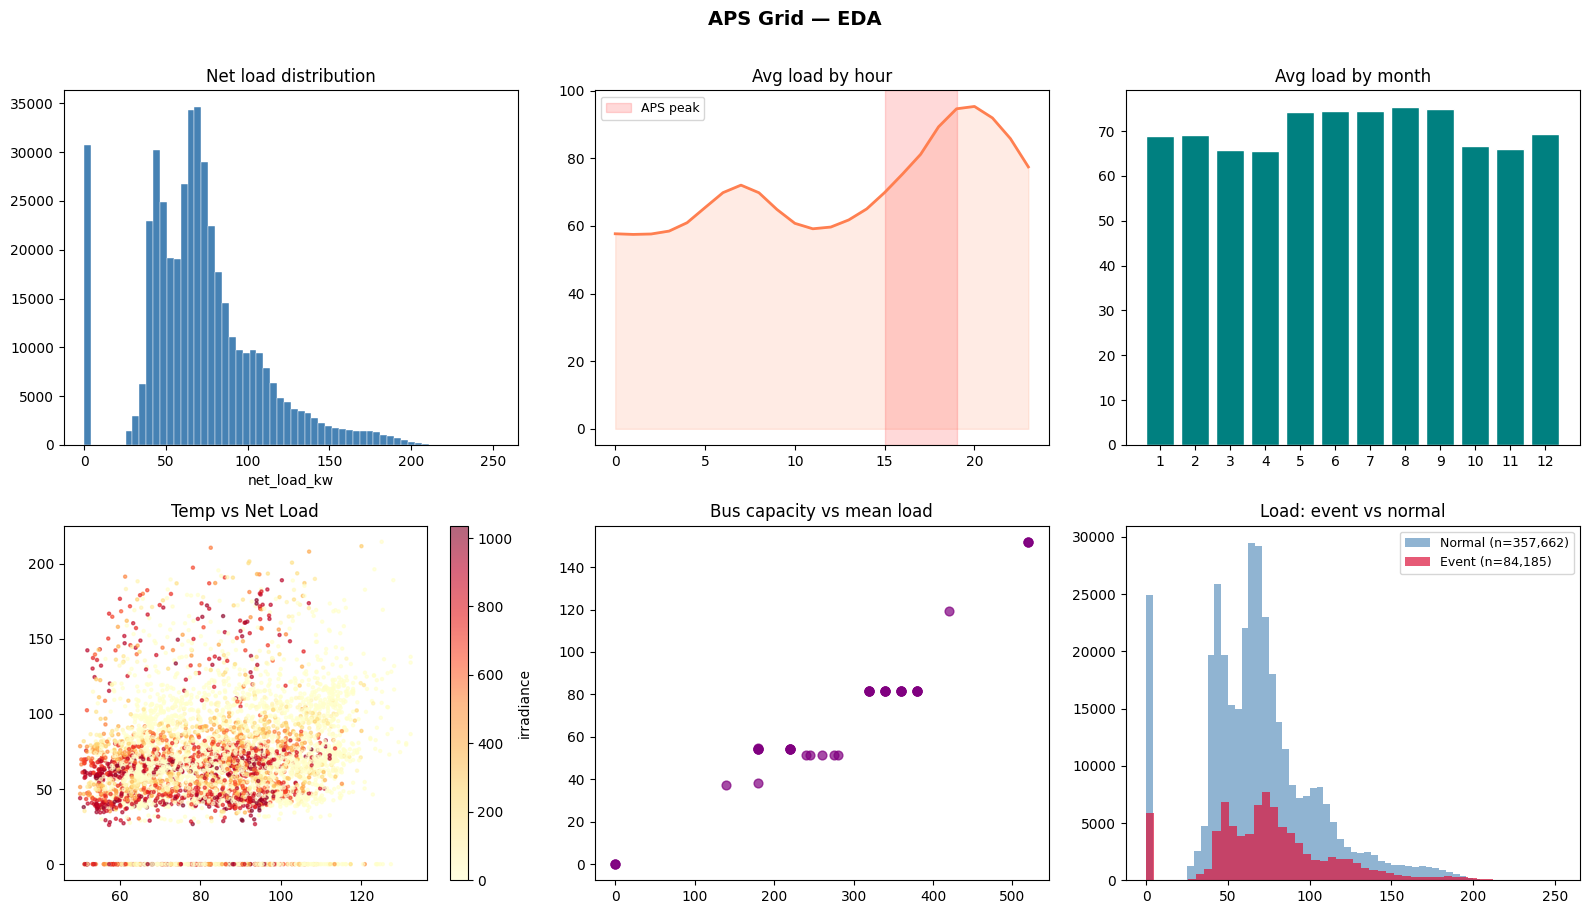

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0,0].hist(df['net_load_kw'], bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0,0].set_title('Net load distribution'); axes[0,0].set_xlabel('net_load_kw')

hr = df.groupby('hour')['net_load_kw'].mean()
axes[0,1].plot(hr.index, hr.values, color='coral', linewidth=2)
axes[0,1].fill_between(hr.index, hr.values, alpha=0.15, color='coral')
axes[0,1].axvspan(15, 19, alpha=0.15, color='red', label='APS peak')
axes[0,1].set_title('Avg load by hour'); axes[0,1].legend(fontsize=9)

mo = df.groupby('month')['net_load_kw'].mean()
axes[0,2].bar(mo.index, mo.values, color='teal', edgecolor='white')
axes[0,2].set_title('Avg load by month'); axes[0,2].set_xticks(range(1,13))

sm = df.sample(5000, random_state=42)
sc = axes[1,0].scatter(sm['temp_f'], sm['net_load_kw'],
                        c=sm['irradiance_wm2'], cmap='YlOrRd', s=5, alpha=0.6)
plt.colorbar(sc, ax=axes[1,0], label='irradiance')
axes[1,0].set_title('Temp vs Net Load')

bs = df.groupby('bus_id').agg(ml=('net_load_kw','mean'), cp=('capacity_kw','first')).reset_index()
axes[1,1].scatter(bs['cp'], bs['ml'], color='purple', s=40, alpha=0.7)
axes[1,1].set_title('Bus capacity vs mean load')

ev  = df[df['is_event_window']==1]['net_load_kw']
nor = df[df['is_event_window']==0]['net_load_kw']
axes[1,2].hist(nor, bins=50, alpha=0.6, label=f'Normal (n={len(nor):,})', color='steelblue')
axes[1,2].hist(ev,  bins=50, alpha=0.7, label=f'Event (n={len(ev):,})',   color='crimson')
axes[1,2].set_title('Load: event vs normal'); axes[1,2].legend(fontsize=9)

plt.suptitle('APS Grid — EDA', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda.png', dpi=130, bbox_inches='tight')
plt.show()


## 6. Graph Construction <a id="6"></a>

In [9]:
edges_df = pd.read_csv(cfg.EDGES_PATH)
print(f'Edges: {edges_df.shape[0]} | Amp range: {edges_df["amp_rating"].min()}-{edges_df["amp_rating"].max()}A')
edges_df.head(5)


Edges: 119 | Amp range: 160-600A


,from_bus,to_bus,edge_type,length_m,r_ohm,x_ohm,amp_rating
0,S0,T01,line,450,0.08,0.04,600
1,T01,T02,line,500,0.08,0.04,600
2,T02,T03,line,550,0.08,0.04,600
3,T03,T04,line,600,0.08,0.04,600
4,T04,T05,line,650,0.08,0.04,600


In [10]:
src = [bus_index[b] for b in edges_df['from_bus'] if b in bus_index]
dst = [bus_index[b] for b in edges_df['to_bus']   if b in bus_index]
edge_index = torch.tensor([src+dst, dst+src], dtype=torch.long)

z_mag = np.sqrt(edges_df['r_ohm']**2 + edges_df['x_ohm']**2).values.astype(np.float32)
amp   = edges_df['amp_rating'].values.astype(np.float32)
z_n   = (z_mag - z_mag.mean()) / (z_mag.std() + 1e-8)
amp_n = (amp   - amp.mean())   / (amp.std()   + 1e-8)
edge_attr = torch.tensor(np.stack([np.tile(z_n,2), np.tile(amp_n,2)], axis=1), dtype=torch.float32)
print(f'edge_index: {edge_index.shape}  edge_attr: {edge_attr.shape}')


edge_index: torch.Size([2, 82])  edge_attr: torch.Size([238, 2])


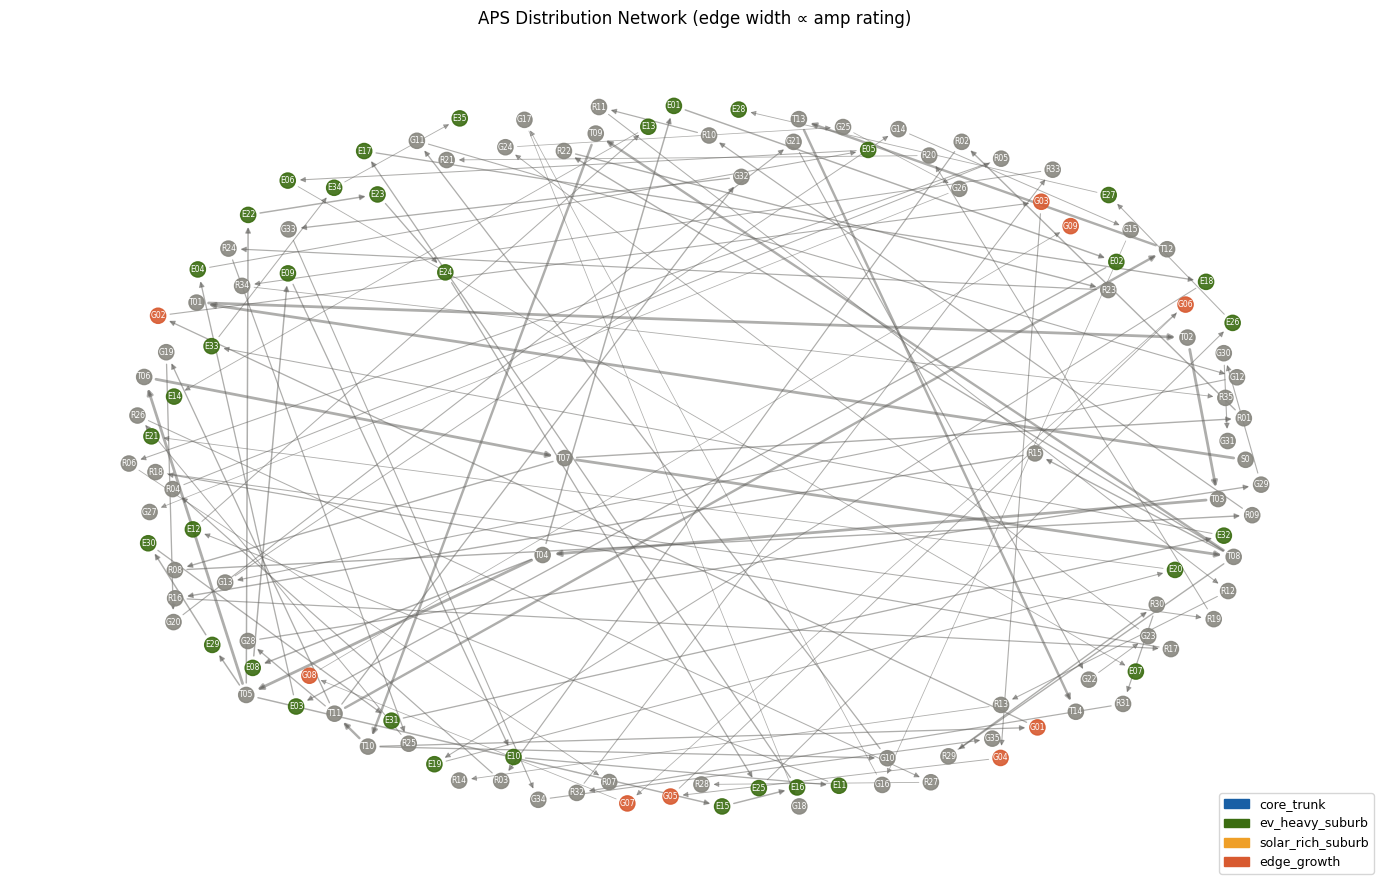

In [11]:
G = nx.DiGraph()
G.add_nodes_from(bus_ids)
for _, row in edges_df.iterrows():
    G.add_edge(row['from_bus'], row['to_bus'], amp=row['amp_rating'])

arche = df.groupby('bus_id')['archetype'].first() if 'archetype' in df.columns else pd.Series(dtype=str)
palette = {'core_trunk':'#185FA5','ev_heavy_suburb':'#3B6D11',
           'solar_rich_suburb':'#EF9F27','edge_growth':'#D85A30'}
node_colors = [palette.get(arche.get(b,''), '#888780') for b in G.nodes()]
ew = [G[u][v]['amp']/300 for u,v in G.edges()]

plt.figure(figsize=(14,9))
pos = nx.spring_layout(G, seed=42, k=1.8)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=120, alpha=0.9)
nx.draw_networkx_edges(G, pos, width=ew, alpha=0.5, edge_color='#5F5E5A', arrows=True, arrowsize=8)
nx.draw_networkx_labels(G, pos, font_size=5.5, font_color='white')
patches = [mpatches.Patch(color=v, label=k) for k,v in palette.items()]
plt.legend(handles=patches, loc='lower right', fontsize=9)
plt.title('APS Distribution Network (edge width ∝ amp rating)', fontsize=12)
plt.axis('off'); plt.tight_layout()
plt.savefig('graph.png', dpi=130, bbox_inches='tight')
plt.show()


## 7. Dataset & DataLoader <a id="7"></a>

In [12]:
class GridDataset(Dataset):
    def __init__(self, node_feat, ts, tgt, start, end):
        self.nf  = torch.tensor(node_feat, dtype=torch.float32)
        self.ts  = torch.tensor(ts,  dtype=torch.float32)
        self.tgt = torch.tensor(tgt, dtype=torch.float32)
        self.idx = list(range(start + cfg.SEQ_LEN, end - cfg.PRED_HORIZON + 1))
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        t = self.idx[i]
        return self.nf, self.ts[t-cfg.SEQ_LEN:t], self.tgt[t+cfg.PRED_HORIZON-1]

t1 = int(T * cfg.TRAIN_FRAC)
t2 = int(T * (cfg.TRAIN_FRAC + cfg.VAL_FRAC))

tr_ds = GridDataset(node_mat, ts_matrix, tgt_matrix, 0, t1)
va_ds = GridDataset(node_mat, ts_matrix, tgt_matrix, t1, t2)
te_ds = GridDataset(node_mat, ts_matrix, tgt_matrix, t2, T)

tr_loader = DataLoader(tr_ds, batch_size=cfg.BATCH, shuffle=True, num_workers=0)
va_loader = DataLoader(va_ds, batch_size=cfg.BATCH, shuffle=False, num_workers=0)
te_loader = DataLoader(te_ds, batch_size=cfg.BATCH, shuffle=False, num_workers=0)
print(f'Train: {len(tr_ds):,} | Val: {len(va_ds):,} | Test: {len(te_ds):,}')


Train: 7,149 | Val: 1,513 | Test: 1,514


## 8. A3T-GCN Model <a id="8"></a>

In [13]:
class A3TGCN(nn.Module):
    def __init__(self, F_node, F_ts):
        super().__init__()
        self.node_enc = nn.Sequential(
            nn.Linear(F_node, cfg.GCN_HIDDEN), nn.ReLU(), nn.Dropout(cfg.DROPOUT))
        self.gcn1  = GCNConv(F_ts + cfg.GCN_HIDDEN, cfg.GCN_HIDDEN)
        self.gcn2  = GCNConv(cfg.GCN_HIDDEN, cfg.GCN_OUT)
        self.gru   = nn.GRUCell(cfg.GCN_OUT, cfg.GRU_HIDDEN)
        self.attn_w = nn.Linear(cfg.GRU_HIDDEN, 1, bias=False)
        self.head  = nn.Sequential(
            nn.Linear(cfg.GRU_HIDDEN, 32), nn.ReLU(),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(32, cfg.PRED_HORIZON))

    def forward(self, node_feat, x_seq, edge_index):
        B, SEQ, N, _ = x_seq.shape
        h_node   = self.node_enc(node_feat)
        h_node_b = h_node.unsqueeze(0).expand(B, -1, -1)
        h = torch.zeros(B*N, cfg.GRU_HIDDEN, device=x_seq.device)
        states = []
        for t in range(SEQ):
            xt = torch.cat([x_seq[:, t], h_node_b], dim=-1)
            gcn_out = torch.stack([
                F.relu(self.gcn2(
                    F.dropout(F.relu(self.gcn1(xt[b], edge_index)),
                              p=cfg.DROPOUT, training=self.training),
                    edge_index))
                for b in range(B)])
            h = self.gru(gcn_out.reshape(B*N, -1), h)
            states.append(h.reshape(B, N, cfg.GRU_HIDDEN))
        stack   = torch.stack(states, dim=2)
        weights = F.softmax(self.attn_w(stack).squeeze(-1), dim=-1).unsqueeze(-1)
        context = (stack * weights).sum(dim=2)
        return self.head(context)

model = A3TGCN(F_node=F_node, F_ts=F_ts).to(DEVICE)
print(f'Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


Params: 29,601


### Training helpers

In [14]:
def make_optimizer(model, lr, wd_base=cfg.WD_BASE, wd_gru=cfg.WD_GRU):
    return torch.optim.Adam([
        {'params': model.node_enc.parameters(), 'weight_decay': wd_base},
        {'params': model.gcn1.parameters(),     'weight_decay': wd_base},
        {'params': model.gcn2.parameters(),     'weight_decay': wd_base},
        {'params': model.gru.parameters(),      'weight_decay': wd_gru},
        {'params': model.attn_w.parameters(),   'weight_decay': wd_base},
        {'params': model.head.parameters(),     'weight_decay': wd_base},
    ], lr=lr)

def train_one_epoch(model, loader, optimizer, edge_index):
    model.train()
    total = 0.0
    for nf, xs, y in loader:
        nf, xs, y = nf[0].to(DEVICE), xs.to(DEVICE), y.to(DEVICE)
        ei = edge_index.to(DEVICE)
        optimizer.zero_grad()
        pred = model(nf, xs, ei).squeeze(-1)
        loss = F.huber_loss(pred, y, delta=cfg.HUBER_DELTA)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    return total / len(loader)

@torch.no_grad()
def evaluate(model, loader, edge_index, tgt_scaler, load_mask=None):
    model.eval()
    all_p, all_t = [], []
    for nf, xs, y in loader:
        nf, xs, y = nf[0].to(DEVICE), xs.to(DEVICE), y.to(DEVICE)
        all_p.append(model(nf, xs, edge_index.to(DEVICE)).squeeze(-1).cpu().numpy())
        all_t.append(y.cpu().numpy())
    P, Y = np.concatenate(all_p), np.concatenate(all_t)
    Nb = P.shape[1]
    Pi = tgt_scaler.inverse_transform(P.reshape(-1,1)).reshape(-1, Nb)
    Yi = tgt_scaler.inverse_transform(Y.reshape(-1,1)).reshape(-1, Nb)
    mae  = mean_absolute_error(Yi.flatten(), Pi.flatten())
    rmse = np.sqrt(mean_squared_error(Yi.flatten(), Pi.flatten()))
    if load_mask is not None:
        Pm, Ym = Pi[:, load_mask], Yi[:, load_mask]
    else:
        Pm, Ym = Pi, Yi
    smape = np.mean(2*np.abs(Ym-Pm)/(np.abs(Ym)+np.abs(Pm)+1e-8)) * 100
    return mae, rmse, smape, Pi, Yi

def run_training(model, tr_loader, va_loader, edge_index, tgt_scaler,
                 n_epochs, lr, load_mask=None, phase_label='Phase 1'):
    optimizer = make_optimizer(model, lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=6, factor=0.5)
    best_val = float('inf')
    best_st  = copy.deepcopy(model.state_dict())
    tr_losses, va_maes = [], []
    prev_lr = lr
    print(f'\n=== {phase_label}: {n_epochs} epochs @ LR={lr} ===')
    print(f"  {'Ep':>4} | {'Train Huber':>11} | {'Val MAE kW':>11} | {'RMSE':>8} | {'sMAPE':>7}")
    print('-' * 54)
    for ep in range(1, n_epochs+1):
        tl = train_one_epoch(model, tr_loader, optimizer, edge_index)
        vm, vr, vs, _, _ = evaluate(model, va_loader, edge_index, tgt_scaler, load_mask)
        scheduler.step(vm)
        cur_lr = optimizer.param_groups[0]['lr']
        if cur_lr < prev_lr:
            print(f'  [LR reduced: {prev_lr:.2e} → {cur_lr:.2e} at epoch {ep}]')
            prev_lr = cur_lr
        tr_losses.append(tl); va_maes.append(vm)
        if vm < best_val:
            best_val = vm
            best_st  = copy.deepcopy(model.state_dict())
        if ep % 5 == 0 or ep == 1:
            print(f'  {ep:>4} | {tl:>11.4f} | {vm:>11.2f} | {vr:>8.2f} | {vs:>6.1f}%')
    print(f'  Best val MAE: {best_val:.2f} kW')
    return best_st, tr_losses, va_maes, best_val


## 9. Training — Phase 1 <a id="9"></a>

In [15]:
best_state_p1, losses_p1, maes_p1, best_val_p1 = run_training(
    model, tr_loader, va_loader, edge_index, tgt_scaler,
    n_epochs=cfg.EPOCHS_P1, lr=cfg.LR,
    load_mask=load_bus_mask,
    phase_label='Phase 1 — warm-up'
)



=== Phase 1 — warm-up: 60 epochs @ LR=0.001 ===
    Ep | Train Huber |  Val MAE kW |     RMSE |   sMAPE
------------------------------------------------------
     1 |      0.2854 |       16.97 |    26.02 |   24.1%
     5 |      0.0649 |        6.76 |     8.93 |   14.4%
    10 |      0.0414 |        5.40 |     7.01 |   12.5%
    15 |      0.0351 |        4.89 |     6.52 |   11.9%
    20 |      0.0316 |        5.17 |     7.14 |   12.2%
    25 |      0.0290 |        4.42 |     5.91 |   11.1%
    30 |      0.0271 |        4.77 |     6.40 |   11.7%
    35 |      0.0252 |        4.36 |     6.06 |   11.0%
    40 |      0.0249 |        4.06 |     5.38 |   10.5%
    45 |      0.0237 |        3.60 |     5.05 |   10.0%
    50 |      0.0232 |        3.53 |     4.67 |   10.1%
  [LR reduced: 1.00e-03 → 5.00e-04 at epoch 54]
    55 |      0.0218 |        3.37 |     4.45 |    9.7%
    60 |      0.0215 |        3.16 |     4.21 |    9.4%
  Best val MAE: 3.12 kW


## 10. Training — Phase 2 <a id="10"></a>

In [16]:
model.load_state_dict(best_state_p1)
best_state_p2, losses_p2, maes_p2, best_val_p2 = run_training(
    model, tr_loader, va_loader, edge_index, tgt_scaler,
    n_epochs=cfg.EPOCHS_P2, lr=cfg.LR_P2,
    load_mask=load_bus_mask,
    phase_label='Phase 2 — fine-tune @ LR=2e-4'
)

best_state = best_state_p2 if best_val_p2 < best_val_p1 else best_state_p1
print(f'\nPhase 1 best: {best_val_p1:.2f} kW | Phase 2 best: {best_val_p2:.2f} kW')
print(f'Overall best: {min(best_val_p1, best_val_p2):.2f} kW')



=== Phase 2 — fine-tune @ LR=2e-4: 40 epochs @ LR=0.0002 ===
    Ep | Train Huber |  Val MAE kW |     RMSE |   sMAPE
------------------------------------------------------
     1 |      0.0215 |        3.09 |     4.14 |    9.2%
     5 |      0.0212 |        3.09 |     4.09 |    9.3%
    10 |      0.0211 |        3.22 |     4.28 |    9.4%
  [LR reduced: 2.00e-04 → 1.00e-04 at epoch 11]
    15 |      0.0208 |        3.28 |     4.36 |    9.6%
    20 |      0.0208 |        3.17 |     4.22 |    9.4%
  [LR reduced: 1.00e-04 → 5.00e-05 at epoch 23]
    25 |      0.0210 |        3.01 |     4.00 |    9.1%
    30 |      0.0207 |        3.06 |     4.07 |    9.2%
  [LR reduced: 5.00e-05 → 2.50e-05 at epoch 32]
    35 |      0.0205 |        3.17 |     4.24 |    9.4%
    40 |      0.0204 |        3.07 |     4.10 |    9.2%
  Best val MAE: 3.00 kW

Phase 1 best: 3.12 kW | Phase 2 best: 3.00 kW
Overall best: 3.00 kW


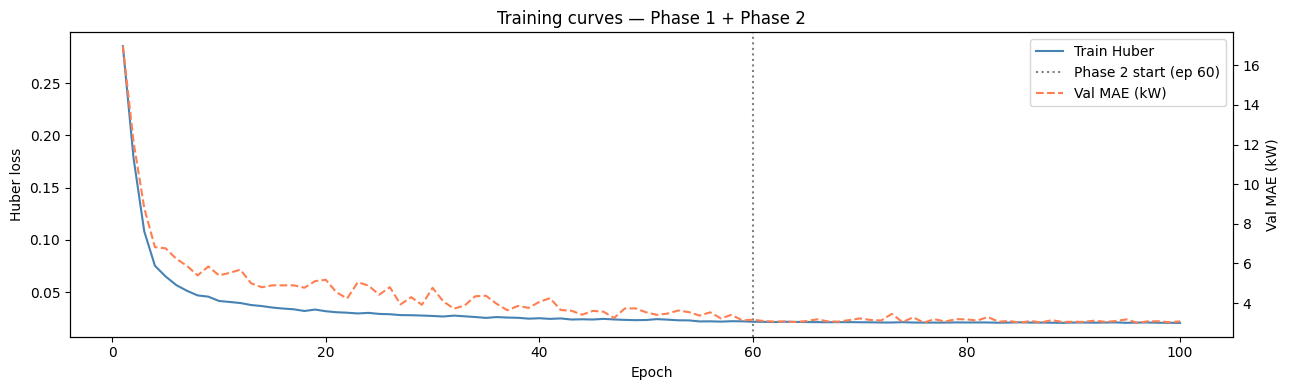

In [17]:
# Combined training curve
all_losses = losses_p1 + losses_p2
all_maes   = maes_p1 + maes_p2
ep_all = list(range(1, len(all_losses)+1))
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ep_all, all_losses, color='steelblue', label='Train Huber')
ax2 = ax.twinx()
ax2.plot(ep_all, all_maes, '--', color='coral', label='Val MAE (kW)')
ax.axvline(x=cfg.EPOCHS_P1, color='gray', linestyle=':', linewidth=1.5,
            label=f'Phase 2 start (ep {cfg.EPOCHS_P1})')
ax.set_xlabel('Epoch'); ax.set_ylabel('Huber loss')
ax2.set_ylabel('Val MAE (kW)')
ax.set_title('Training curves — Phase 1 + Phase 2')
l1, lab1 = ax.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax.legend(l1+l2, lab1+lab2, loc='upper right')
plt.tight_layout(); plt.savefig('training_curves.png', dpi=130, bbox_inches='tight')
plt.show()


## 11. Evaluation & Scenario Analysis <a id="11"></a>

In [18]:
model.load_state_dict(best_state)
test_mae, test_rmse, test_smape, preds, trues = \
    evaluate(model, te_loader, edge_index, tgt_scaler, load_mask=load_bus_mask)

print('=' * 44)
print(f'  Test MAE   : {test_mae:.2f} kW')
print(f'  Test RMSE  : {test_rmse:.2f} kW')
print(f'  Test sMAPE : {test_smape:.1f} %  (load buses only)')
print('=' * 44)


  Test MAE   : 2.91 kW
  Test RMSE  : 3.90 kW
  Test sMAPE : 9.2 %  (load buses only)


In [19]:
# Scenario breakdown
test_timestamps = timestamps[t2 + cfg.SEQ_LEN : T - cfg.PRED_HORIZON + 1]
test_meta = (
    df[df['timestamp'].isin(test_timestamps)]
    .groupby('timestamp')[['extreme_heat_flag','heatwave_flag','is_peak_window_aps']]
    .first().reindex(test_timestamps).fillna(0)
)
heat_mask = test_meta['extreme_heat_flag'].values.astype(bool)
hw_mask   = test_meta['heatwave_flag'].values.astype(bool)
peak_mask = test_meta['is_peak_window_aps'].values.astype(bool)

def sc_mae(m):
    return float('nan') if m.sum()==0 else mean_absolute_error(trues[m].flatten(), preds[m].flatten())
def sc_rmse(m):
    return float('nan') if m.sum()==0 else np.sqrt(mean_squared_error(trues[m].flatten(), preds[m].flatten()))

print('=' * 56)
print('  SCENARIO EVALUATION')
print('=' * 56)
scenarios = [
    ('Baseline (all test)',      np.ones(len(trues), dtype=bool)),
    ('Extreme heat hours',       heat_mask),
    ('Heatwave hours',           hw_mask),
    ('APS peak window (3-7 PM)', peak_mask),
    ('Peak + extreme heat',      peak_mask & heat_mask),
]
for name, m in scenarios:
    if m.sum() == 0:
        print(f'  {name:<30} n=0 (not present in test window)')
    else:
        print(f'  {name:<30} MAE: {sc_mae(m):5.2f} kW  RMSE: {sc_rmse(m):5.2f} kW  (n={m.sum()})')
print('=' * 56)

mae_heat      = sc_mae(heat_mask)
mae_peak      = sc_mae(peak_mask)
mae_peak_heat = sc_mae(peak_mask & heat_mask)


  SCENARIO EVALUATION
  Baseline (all test)            MAE:  2.91 kW  RMSE:  3.90 kW  (n=1514)
  Extreme heat hours             MAE:  3.69 kW  RMSE:  4.84 kW  (n=125)
  Heatwave hours                 n=0 (not present in test window)
  APS peak window (3-7 PM)       MAE:  3.27 kW  RMSE:  4.29 kW  (n=189)
  Peak + extreme heat            MAE:  3.74 kW  RMSE:  4.89 kW  (n=16)


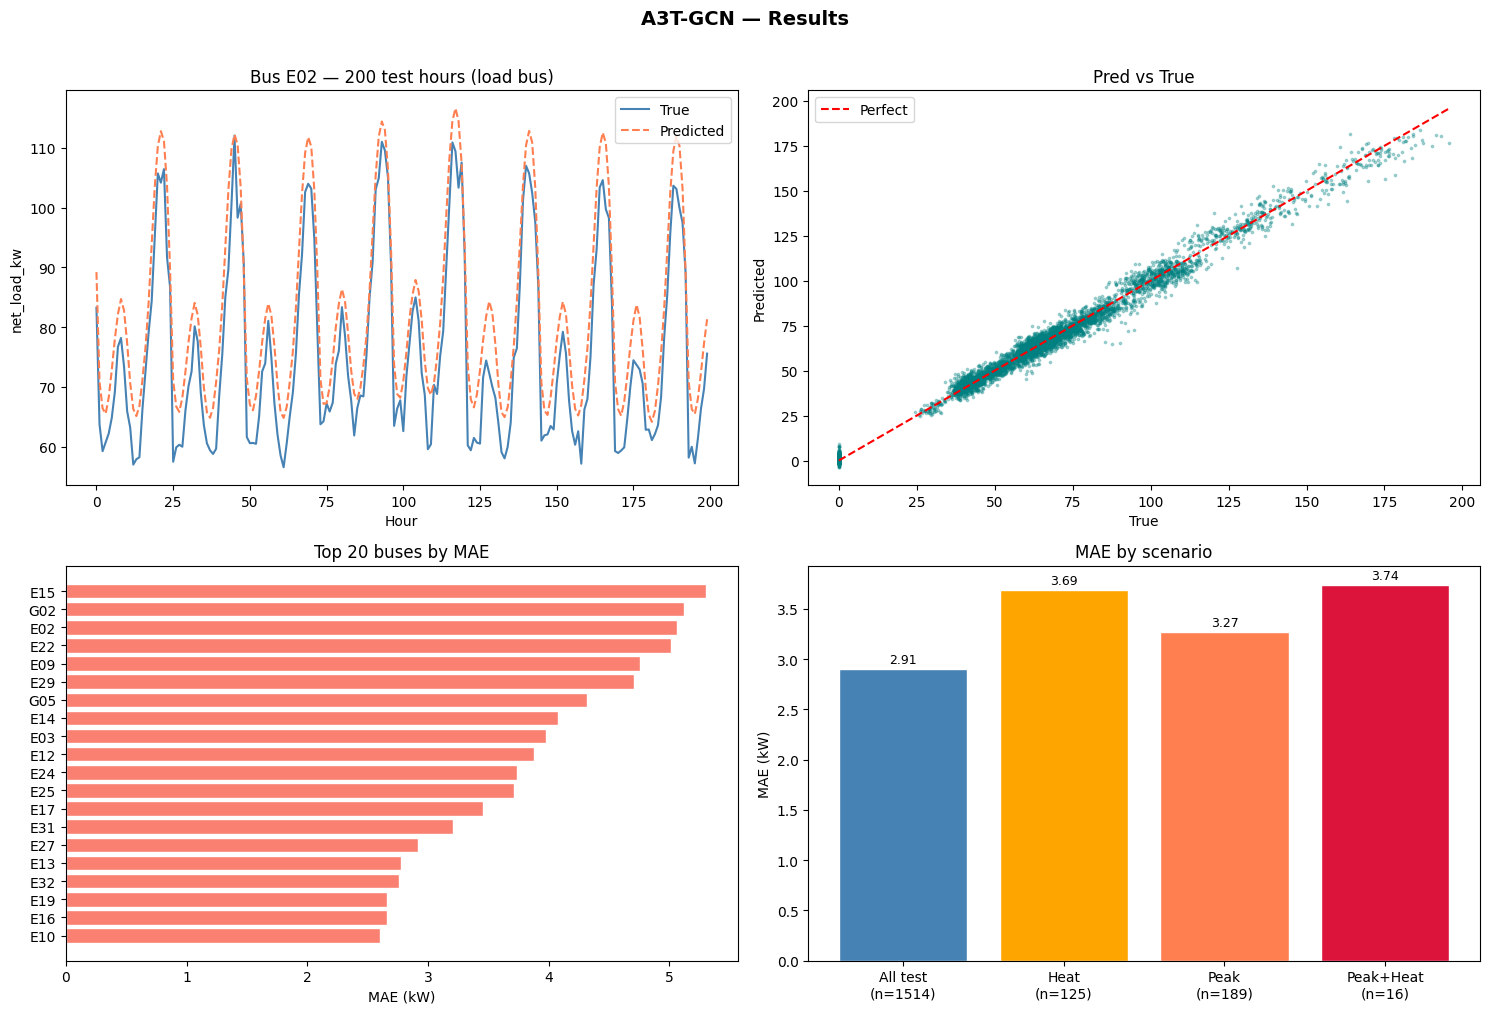

In [20]:
# Per-bus MAE
bus_mae_vals = [mean_absolute_error(trues[:,i], preds[:,i]) for i in range(N)]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# FIX: plot a real load bus
load_bus_idx = int(np.where(load_bus_mask)[0][0])
ax = axes[0,0]
ax.plot(trues[:200, load_bus_idx], label='True', linewidth=1.5, color='steelblue')
ax.plot(preds[:200, load_bus_idx], '--', label='Predicted', linewidth=1.5, color='coral')
ax.set_title(f'Bus {bus_ids[load_bus_idx]} — 200 test hours (load bus)')
ax.set_xlabel('Hour'); ax.set_ylabel('net_load_kw'); ax.legend()

ax = axes[0,1]
fp, ft = preds.flatten(), trues.flatten()
idx = np.random.choice(len(fp), min(5000,len(fp)), replace=False)
ax.scatter(ft[idx], fp[idx], s=3, alpha=0.3, color='teal')
ax.plot([ft.min(),ft.max()],[ft.min(),ft.max()],'r--',lw=1.5,label='Perfect')
ax.set_xlabel('True'); ax.set_ylabel('Predicted'); ax.set_title('Pred vs True'); ax.legend()

top20 = np.argsort(bus_mae_vals)[::-1][:20]
ax = axes[1,0]
ax.barh([bus_ids[i] for i in top20], [bus_mae_vals[i] for i in top20],
         color='salmon', edgecolor='white')
ax.set_xlabel('MAE (kW)'); ax.set_title('Top 20 buses by MAE'); ax.invert_yaxis()

# FIX: filter empty scenarios
ax = axes[1,1]
sc_names_raw = ['All test', 'Heat', 'Heatwave', 'Peak', 'Peak+Heat']
sc_masks_raw = [np.ones(len(trues), dtype=bool), heat_mask, hw_mask,
                peak_mask, peak_mask & heat_mask]
all_colors = ['steelblue','orange','tomato','coral','crimson']
sc_names, sc_maes_v, sc_colors = [], [], []
for name, m, c in zip(sc_names_raw, sc_masks_raw, all_colors):
    if m.sum() > 0:
        sc_names.append(f'{name}\n(n={m.sum()})')
        sc_maes_v.append(sc_mae(m))
        sc_colors.append(c)
bars = ax.bar(sc_names, sc_maes_v, color=sc_colors, edgecolor='white')
ax.bar_label(bars, fmt='%.2f', fontsize=9, padding=2)
ax.set_ylabel('MAE (kW)'); ax.set_title('MAE by scenario')

plt.suptitle('A3T-GCN — Results', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('results.png', dpi=130, bbox_inches='tight')
plt.show()


## 12. Decision Layer <a id="12"></a>

FIX: Uses **percentile rank** so `HIGH` tier correctly means highest error. Weights peak-hour error 60% vs overall 40% since peak errors matter more operationally.

In [21]:
bus_result = pd.DataFrame({
    'bus_id'   : bus_ids,
    'mae_kw'   : bus_mae_vals,
    'rmse_kw'  : [np.sqrt(mean_squared_error(trues[:,i],preds[:,i])) for i in range(N)],
    'smape_pct': [np.mean(2*np.abs(trues[:,i]-preds[:,i])/
                  (np.abs(trues[:,i])+np.abs(preds[:,i])+1e-8))*100 for i in range(N)],
    'peak_mae_kw': [mean_absolute_error(trues[peak_mask,i], preds[peak_mask,i])
                    if peak_mask.sum()>0 else np.nan for i in range(N)],
    'heat_mae_kw': [mean_absolute_error(trues[heat_mask,i], preds[heat_mask,i])
                    if heat_mask.sum()>0 else np.nan for i in range(N)],
    'is_load_bus': load_bus_mask,
}).sort_values('mae_kw', ascending=False).reset_index(drop=True)

# Percentile rank — higher = higher error = higher risk
bus_result['mae_pct']      = bus_result['mae_kw'].rank(pct=True)
bus_result['peak_mae_pct'] = bus_result['peak_mae_kw'].rank(pct=True)
bus_result['risk_score']   = (0.4 * bus_result['mae_pct'] +
                               0.6 * bus_result['peak_mae_pct'])
bus_result['risk_tier'] = pd.cut(
    bus_result['risk_score'],
    bins=[0, 0.33, 0.66, 1.01],
    labels=['LOW','MEDIUM','HIGH']
)

print('Top 10 hardest buses:')
print(bus_result[['bus_id','mae_kw','peak_mae_kw','heat_mae_kw','risk_tier']].head(10).to_string(index=False))


Top 10 hardest buses:
bus_id   mae_kw  peak_mae_kw  heat_mae_kw risk_tier
   E15 5.299947     5.441477     4.301452      HIGH
   G02 5.120442     6.039883     6.488154      HIGH
   E02 5.063910     5.197554     6.836288      HIGH
   E22 5.015133     4.577445     4.802131      HIGH
   E09 4.758614     7.018109     9.244226      HIGH
   E29 4.709148     4.549891     4.252277      HIGH
   G05 4.317351     3.781900     5.682138      HIGH
   E14 4.076259     4.894181     6.019163      HIGH
   E03 3.974009     5.310981     6.044704      HIGH
   E12 3.874928     5.052744     6.157784      HIGH


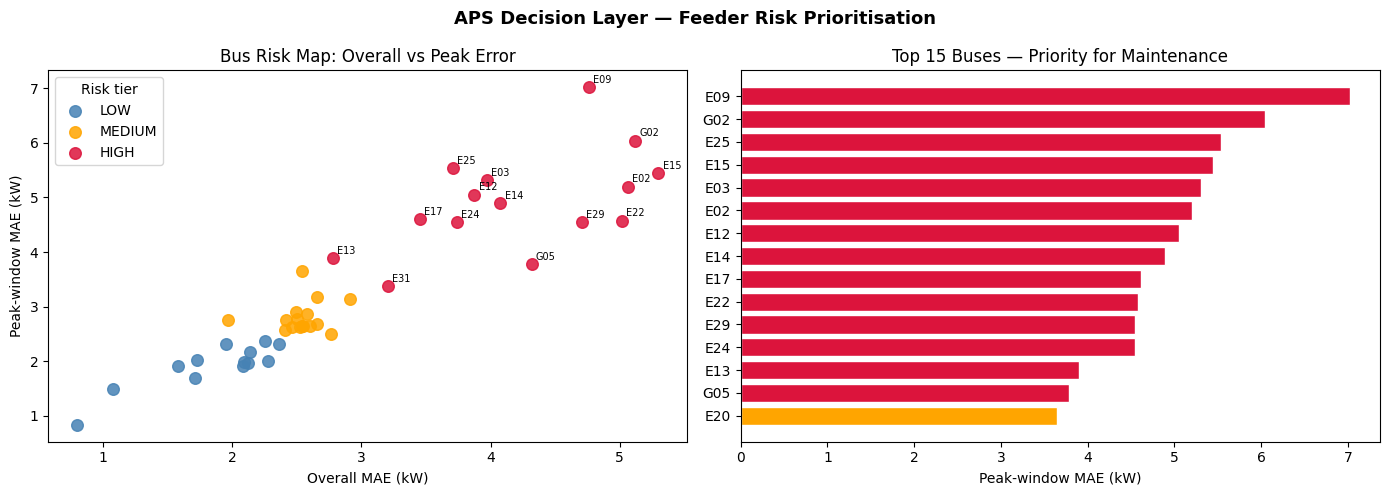


=== Recommended Actions ===
1. Inspect 15 HIGH-risk buses: ['E15', 'G02', 'E02', 'E22', 'E09', 'E29', 'G05', 'E14', 'E03', 'E12', 'E24', 'E25', 'E17', 'E31', 'E13']
2. Priority 1 bus: E09 (peak MAE 7.02 kW, tier: HIGH)
3. Pre-position switching resources before next heatwave window.
4. Monitor EV charging overlap on peak-hour high-error buses.


In [22]:
colors = {'HIGH':'crimson','MEDIUM':'orange','LOW':'steelblue'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for tier, grp in bus_result.groupby('risk_tier'):
    axes[0].scatter(grp['mae_kw'], grp['peak_mae_kw'],
                    label=tier, color=colors[tier], s=70, alpha=0.85)
axes[0].set_xlabel('Overall MAE (kW)'); axes[0].set_ylabel('Peak-window MAE (kW)')
axes[0].set_title('Bus Risk Map: Overall vs Peak Error')
axes[0].legend(title='Risk tier')
for _, row in bus_result[bus_result['risk_tier']=='HIGH'].iterrows():
    axes[0].annotate(row['bus_id'], (row['mae_kw'], row['peak_mae_kw']),
                     fontsize=7, xytext=(3,3), textcoords='offset points')

top15 = bus_result.sort_values('peak_mae_kw', ascending=False).head(15)
bar_colors = [colors.get(str(t),'gray') for t in top15['risk_tier']]
axes[1].barh(top15['bus_id'].astype(str), top15['peak_mae_kw'],
             color=bar_colors, edgecolor='white')
axes[1].set_xlabel('Peak-window MAE (kW)')
axes[1].set_title('Top 15 Buses — Priority for Maintenance')
axes[1].invert_yaxis()

plt.suptitle('APS Decision Layer — Feeder Risk Prioritisation', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('decision_layer.png', dpi=130, bbox_inches='tight')
plt.show()

high_risk = bus_result[bus_result['risk_tier']=='HIGH']
worst = bus_result.sort_values('peak_mae_kw', ascending=False).iloc[0]
print('\n=== Recommended Actions ===')
print(f'1. Inspect {len(high_risk)} HIGH-risk buses: {high_risk["bus_id"].tolist()}')
print(f'2. Priority 1 bus: {worst["bus_id"]} (peak MAE {worst["peak_mae_kw"]:.2f} kW, tier: {worst["risk_tier"]})')
print('3. Pre-position switching resources before next heatwave window.')
print('4. Monitor EV charging overlap on peak-hour high-error buses.')


## 13. Save & Inference <a id="13"></a>

In [23]:
torch.save({
    'model_state'  : best_state,
    'ts_features'  : TS_FEATURES,
    'node_features': NODE_FEATURES,
    'ts_scaler'    : ts_scaler,
    'tgt_scaler'   : tgt_scaler,
    'nd_scaler'    : nd_scaler,
    'bus_ids'      : bus_ids,
    'edge_index'   : edge_index,
    'edge_attr'    : edge_attr,
    'load_bus_mask': load_bus_mask,
    'cfg'          : {k:v for k,v in vars(cfg).items() if not k.startswith('_')},
    'test_mae'     : test_mae, 'test_rmse': test_rmse, 'test_smape': test_smape,
    'mae_heat'     : mae_heat, 'mae_peak': mae_peak, 'mae_peak_heat': mae_peak_heat,
    'bus_result'   : bus_result,
}, 'a3tgcn_best.pt')
print('Checkpoint saved → a3tgcn_best.pt')


Checkpoint saved → a3tgcn_best.pt


In [24]:
def predict_next_hour(checkpoint_path, recent_df):
    """Predict t+1 net_load for every bus given 24h recent history."""
    ckpt  = torch.load(checkpoint_path, map_location='cpu')
    ts_f  = ckpt['ts_features']
    nd_f  = ckpt['node_features']
    buses = ckpt['bus_ids']
    ei    = ckpt['edge_index']
    SEQ   = ckpt['cfg']['SEQ_LEN']
    Nb    = len(buses)
    bidx  = {b:i for i,b in enumerate(buses)}

    ts_arr = np.zeros((SEQ, Nb, len(ts_f)), dtype=np.float32)
    nd_arr = np.zeros((Nb, len(nd_f)), dtype=np.float32)

    for step, (_, grp) in enumerate(recent_df.groupby('timestamp', sort=True)):
        for _, row in grp.iterrows():
            n = bidx.get(row['bus_id'])
            if n is None: continue
            ts_arr[step, n, :] = row[ts_f].values.astype(np.float32)
            nd_arr[n, :]       = row[nd_f].values.astype(np.float32)

    ts_arr = ckpt['ts_scaler'].transform(ts_arr.reshape(-1, len(ts_f))).reshape(SEQ, Nb, -1)
    nd_arr = ckpt['nd_scaler'].transform(nd_arr)

    xs = torch.tensor(ts_arr, dtype=torch.float32).unsqueeze(0)
    nf = torch.tensor(nd_arr, dtype=torch.float32)

    m = A3TGCN(F_node=len(nd_f), F_ts=len(ts_f))
    m.load_state_dict(ckpt['model_state'])
    m.eval()
    with torch.no_grad():
        raw = m(nf, xs, ei).squeeze(0).squeeze(-1).numpy()
    preds_kw = ckpt['tgt_scaler'].inverse_transform(raw.reshape(-1,1)).flatten()
    out = pd.DataFrame({'bus_id': buses, 'predicted_net_load_kw': preds_kw})
    if 'bus_result' in ckpt:
        out = out.merge(ckpt['bus_result'][['bus_id','risk_tier']], on='bus_id', how='left')
    return out.sort_values('bus_id').reset_index(drop=True)

print('predict_next_hour() ready.')


predict_next_hour() ready.
